In [1]:
!pip install wrds pandas matplotlib streamlit numpy

In [4]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
db = wrds.Connection(wrds_username="zhouzhou928")

Loading library list...
Done


In [7]:
query = """
SELECT
    tic, conm, datadate,
    revt  AS revenue,
    ni    AS net_income,
    at    AS total_assets,
    lt    AS total_liabilities,
    act   AS current_assets,
    lct   AS current_liabilities,
    ceq   AS equity,
    oancf AS operating_cash_flow
FROM comp.funda
WHERE
    tic = '{}'
    AND indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
    AND EXTRACT(YEAR FROM datadate) BETWEEN 2015 AND 2023
ORDER BY datadate;
"""

In [8]:
df_aapl = db.raw_sql(query.format('AAPL'))
df_aapl.head()

,tic,conm,datadate,revenue,net_income,total_assets,total_liabilities,current_assets,current_liabilities,equity,operating_cash_flow
0,AAPL,APPLE INC,2015-09-30,233715.0,53394.0,290479.0,171124.0,89378.0,80610.0,119355.0,81266.0
1,AAPL,APPLE INC,2016-09-30,215091.0,45687.0,321686.0,193437.0,106869.0,79006.0,128249.0,65824.0
2,AAPL,APPLE INC,2017-09-30,229234.0,48351.0,375319.0,241272.0,128645.0,100814.0,134047.0,63598.0
3,AAPL,APPLE INC,2018-09-30,265359.0,59531.0,365725.0,258578.0,131339.0,116866.0,107147.0,77434.0
4,AAPL,APPLE INC,2019-09-30,260174.0,55256.0,338516.0,248028.0,162819.0,105718.0,90488.0,69391.0


In [9]:
df_msft = db.raw_sql(query.format('MSFT'))
df_msft.head()

,tic,conm,datadate,revenue,net_income,total_assets,total_liabilities,current_assets,current_liabilities,equity,operating_cash_flow
0,MSFT,MICROSOFT CORP,2015-06-30,93580.0,12193.0,176223.0,96140.0,124712.0,49858.0,80083.0,29080.0
1,MSFT,MICROSOFT CORP,2016-06-30,85320.0,16798.0,193694.0,121697.0,139660.0,59357.0,71997.0,33325.0
2,MSFT,MICROSOFT CORP,2017-06-30,89950.0,21204.0,241086.0,168692.0,159851.0,64527.0,72394.0,39507.0
3,MSFT,MICROSOFT CORP,2018-06-30,110360.0,16571.0,258848.0,176130.0,169662.0,58488.0,82718.0,43884.0
4,MSFT,MICROSOFT CORP,2019-06-30,125843.0,39240.0,286556.0,184226.0,175552.0,69420.0,102330.0,52185.0


In [19]:
def compute_ratios(df):
    df = df.copy()
   
    df['datadate'] = pd.to_datetime(df['datadate'])
    df['year'] = df['datadate'].dt.year

   
    df['net_profit_margin'] = (df['net_income'] / df['revenue']) * 100
    df['roe'] = (df['net_income'] / df['equity']) * 100


    df['debt_asset_ratio'] = (df['total_liabilities'] / df['total_assets']) * 100
    df['current_ratio'] = df['current_assets'] / df['current_liabilities']

   
    df['asset_turnover'] = df['revenue'] / df['total_assets']

   
    df['ocf_ratio'] = (df['operating_cash_flow'] / df['revenue']) * 100

    return df

In [20]:
df_aapl['datadate'] = pd.to_datetime(df_aapl['datadate'])
df_msft['datadate'] = pd.to_datetime(df_msft['datadate'])

In [21]:
df_aapl = compute_ratios(df_aapl)
df_msft = compute_ratios(df_msft)

In [22]:
aapl_table = df_aapl[[
    'year', 'revenue', 'net_income',
    'net_profit_margin', 'debt_asset_ratio',
    'asset_turnover', 'roe'
]].round(2)

print("Apple Inc. Financial Summary")
print(aapl_table)

Apple Inc. Financial Summary
   year   revenue  net_income  net_profit_margin  debt_asset_ratio  \
0  2015  233715.0     53394.0              22.85             58.91   
1  2016  215091.0     45687.0              21.24             60.13   
2  2017  229234.0     48351.0              21.09             64.28   
3  2018  265359.0     59531.0              22.43              70.7   
4  2019  260174.0     55256.0              21.24             73.27   
5  2020  274515.0     57411.0              20.91             79.83   
6  2021  365817.0     94680.0              25.88             82.03   
7  2022  394328.0     99803.0              25.31             85.64   
8  2023  383285.0     96995.0              25.31             82.37   

   asset_turnover     roe  
0             0.8   44.74  
1            0.67   35.62  
2            0.61   36.07  
3            0.73   55.56  
4            0.77   61.06  
5            0.85   87.87  
6            1.04  150.07  
7            1.12  196.96  
8            1.09 

In [23]:
msft_table = df_msft[[
    'year', 'revenue', 'net_income',
    'net_profit_margin', 'debt_asset_ratio',
    'asset_turnover', 'roe'
]].round(2)

print("Microsoft Corp. Financial Summary")
print(msft_table)

Microsoft Corp. Financial Summary
   year   revenue  net_income  net_profit_margin  debt_asset_ratio  \
0  2015   93580.0     12193.0              13.03             54.56   
1  2016   85320.0     16798.0              19.69             62.83   
2  2017   89950.0     21204.0              23.57             69.97   
3  2018  110360.0     16571.0              15.02             68.04   
4  2019  125843.0     39240.0              31.18             64.29   
5  2020  143015.0     44281.0              30.96             60.74   
6  2021  168088.0     61271.0              36.45             57.46   
7  2022  198270.0     72738.0              36.69             54.35   
8  2023  211915.0     72361.0              34.15             49.94   

   asset_turnover    roe  
0            0.53  15.23  
1            0.44  23.33  
2            0.37  29.29  
3            0.43  20.03  
4            0.44  38.35  
5            0.47  37.43  
6             0.5  43.15  
7            0.54  43.68  
8            0.51  35.

In [24]:
df_aapl.to_csv("data_aapl.csv", index=False)
df_msft.to_csv("data_msft.csv", index=False)
print("Files saved successfully!")

Files saved successfully!


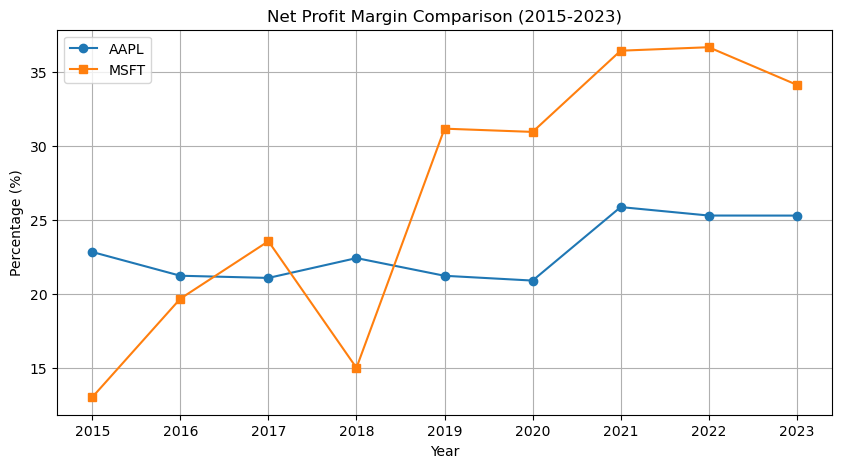

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(df_aapl['year'], df_aapl['net_profit_margin'], marker='o', label='AAPL')
plt.plot(df_msft['year'], df_msft['net_profit_margin'], marker='s', label='MSFT')
plt.title('Net Profit Margin Comparison (2015-2023)')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True)
plt.show()

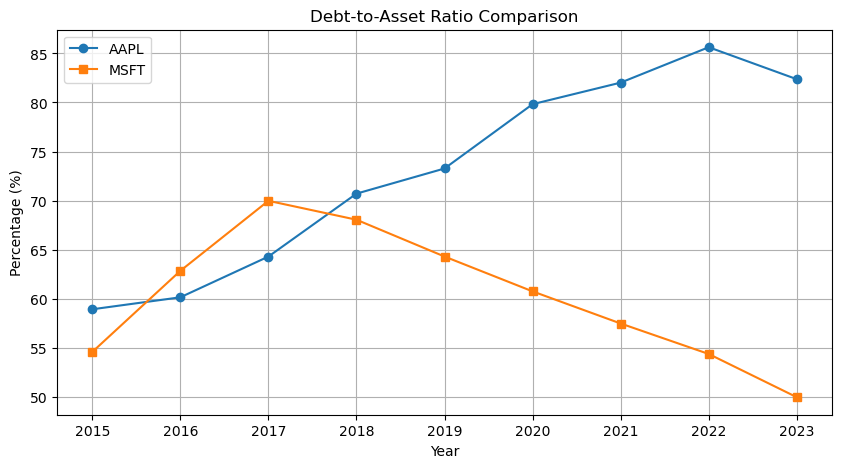

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(df_aapl['year'], df_aapl['debt_asset_ratio'], marker='o', label='AAPL')
plt.plot(df_msft['year'], df_msft['debt_asset_ratio'], marker='s', label='MSFT')
plt.title('Debt-to-Asset Ratio Comparison')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True)
plt.show()

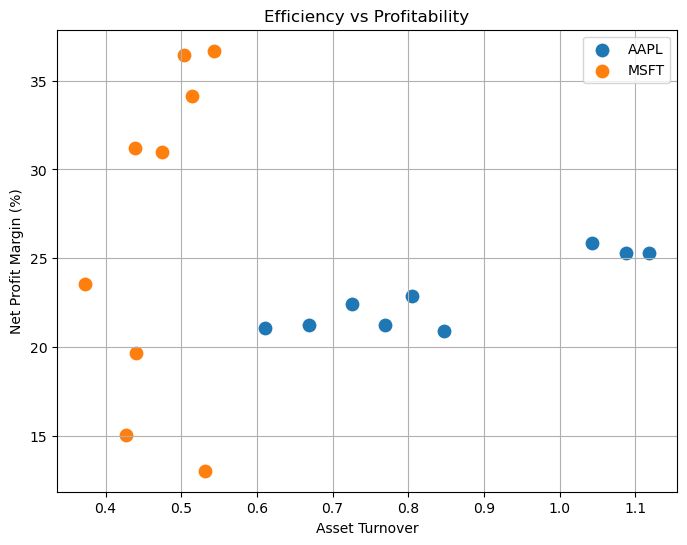

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(df_aapl['asset_turnover'], df_aapl['net_profit_margin'], s=80, label='AAPL')
plt.scatter(df_msft['asset_turnover'], df_msft['net_profit_margin'], s=80, label='MSFT')
plt.xlabel('Asset Turnover')
plt.ylabel('Net Profit Margin (%)')
plt.title('Efficiency vs Profitability')
plt.legend()
plt.grid(True)
plt.show()

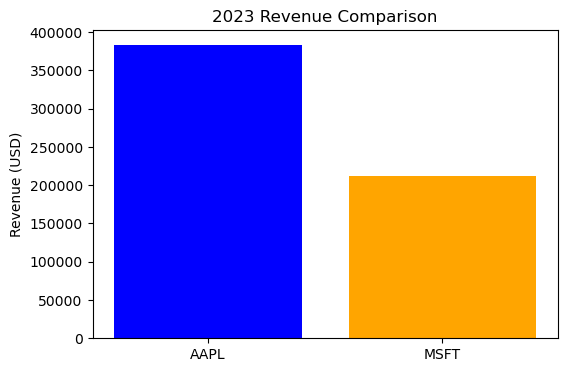

In [28]:
aapl_rev = df_aapl[df_aapl['year'] == 2023]['revenue'].values[0]
msft_rev = df_msft[df_msft['year'] == 2023]['revenue'].values[0]

plt.figure(figsize=(6, 4))
plt.bar(['AAPL', 'MSFT'], [aapl_rev, msft_rev], color=['blue', 'orange'])
plt.title('2023 Revenue Comparison')
plt.ylabel('Revenue (USD)')
plt.show()

In [ ]:
!streamlit run app.py


      👋 Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  